In [1]:
import PKA_Sleep as PKA #Primary analysis code package
import os

In [7]:
epoch_len = 4 #Sleep scoring epoch length
filter_bounds = [None, None] #Filtering for photometry
binned = False #True/False binned photometry
shuffle_window = 200 #Chunks of photometry that will be shuffled
experimental_sensor = 'FLIM-AKAR' #Sensor name
sleep_states = True #True/False include sleep scoring
microarousals = True #True/False microarousals changed from 1->5 (True: MA = 5; False: not distinguishable from wake)
seperate_acqs = False #True/False (True: makes individual FLiP class for every acquisition)
emp_lifetime = False #True/False include empirical lifetime
gather_timestamps = False #True/False include acqusiiont start timestamps
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/' #parents directory of raw data

experiment_names = [
    ['ltFLiPAKAREEGEMG0065',
     'ltFLiPAKAREEGEMG0066',
     'ltFLiPAKAREEGEMG0067',
     'ltFLiPAKAREEGEMG0073',
     'ltFLiPAKAREEGEMG0080',
     'ltFLiPAKAREEGEMG0081',
     'ltFLiPAKAREEGEMG0082',
     'ltFLiPAKAREEGEMG0083',
     'ltFLiPAKAREEGEMG0084'],
    ['ltFLiPAKAREEGEMG0076',
     'ltFLiPAKAREEGEMG0077',
     'ltFLiPAKAREEGEMG0078',
     'ltFLiPAKAREEGEMG0079',
     'ltFLiPAKAREEGEMG0095',
     'ltFLiPAKAREEGEMG0097',
     'ltFLiPAKAREEGEMG0098']
]
mouse_names = [
    ['2647-10',
    '2642-8',
    '2647-10',
    '2647-10',
    '3016-1',
    '2896-1',
    '2894',
    '2894',
    '2894'],
    ['2987-t14',
     '2987-t14',
     '2986-t11',
     '2987-t14',
     '4344',
     '5184',
     '5183']
]

df = pd.read_excel('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/FLiP_Experiment_Summary.xlsx')
raw_datadirs = [[os.path.join(parent_data_directory, e) for e in experiment_names[i]] 
                for i in range(len(experiment_names))] #nested lists of raw data directories (control and experimental)

baseline_idxs = [[(int(d['Baseline Start'].values),int(d['Baseline End'].values)) 
                  for d in [df.loc[df['Experiment Name'] == e] for e in exp_list]] for exp_list in experiment_names]
excluded_acqs = [PKA.choose_excluded_acqs(raw_datadirs[r], first_acqs = 3, specific_acqs = False, 
                                          pull_baseline = True, baseline_idxs = baseline_idxs[r]) for r in range(len(raw_datadirs))]
   
FLP_classes_dicts = [PKA.build_classes(experiment_names[i], mouse_names[i], epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                       exclude_acqs = excluded_acqs[i]) for i in range(len(experiment_names))]

You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this expe

In [8]:
# savedir = False
raw_lifetime = False # True/False (True: Plotting raw or ZScored; False: zeroed lifetime)
if raw_lifetime:
    raw_str = 'raw'
else:
    raw_str = ''
zscore = False #True/False (True: plotting zscore)
if zscore:
    zscore_str = 'ZScore'
else:
    zscore_str = ''

figure_dir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_1/'
cre_line = 'CamKII'
delivery_method = 'ICI'
brain_region = 'Dorsal CA1'
transition_types = 'alltrans'
if filter_bounds == [None, None]:
    filter_status = 'nofilter'
else:
    filter_status = str(filter_bounds[0])+'-'+str(filter_bounds[1])
fig_ext = '.ps'
fn = cre_line+'_'+delivery_method+'_'+experimental_sensor+'_'+brain_region+'_'+transition_types+'_'+filter_status+raw_str+zscore_str+fig_ext
savedir = os.path.join(figure_dir, fn)

Working on ltFLiPAKAREEGEMG0065...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0066...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0067...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0073...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0080...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0081...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0082...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0083...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0084...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
['NREM-Wake', 'NREM-Wake Long', 'NREM-Wake Short']


Which of the above conditions do you want to plot? NREM-Wake


['Wake-NREM', 'Wake-NREM Long', 'Wake-NREM Short']


Which of the above conditions do you want to plot? Wake-NREM Long


/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/genPKA_Dynamics.py:740: RuntimeWarning: Mean of empty slice
  all_dicts[a]['Average ' + data_key] = {g: {s: average_function(np.concatenate(all_dicts[a][data_key][g][s], axis = 0), axis = 0)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Working on ltFLiPAKAREEGEMG0076...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0077...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0078...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0079...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0095...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0097...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
Working on ltFLiPAKAREEGEMG0098...
Wake-NREM
NREM-REM
NREM-Wake
REM-Wake
Microarousals
['NREM-Wake', 'NREM-Wake Long', 'NREM-Wake Short']


Which of the above conditions do you want to plot? NREM-Wake


['Wake-NREM', 'Wake-NREM Long', 'Wake-NREM Short']


Which of the above conditions do you want to plot? Wake-NREM Long


/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/genPKA_Dynamics.py:740: RuntimeWarning: Mean of empty slice
  all_dicts[a]['Average ' + data_key] = {g: {s: average_function(np.concatenate(all_dicts[a][data_key][g][s], axis = 0), axis = 0)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


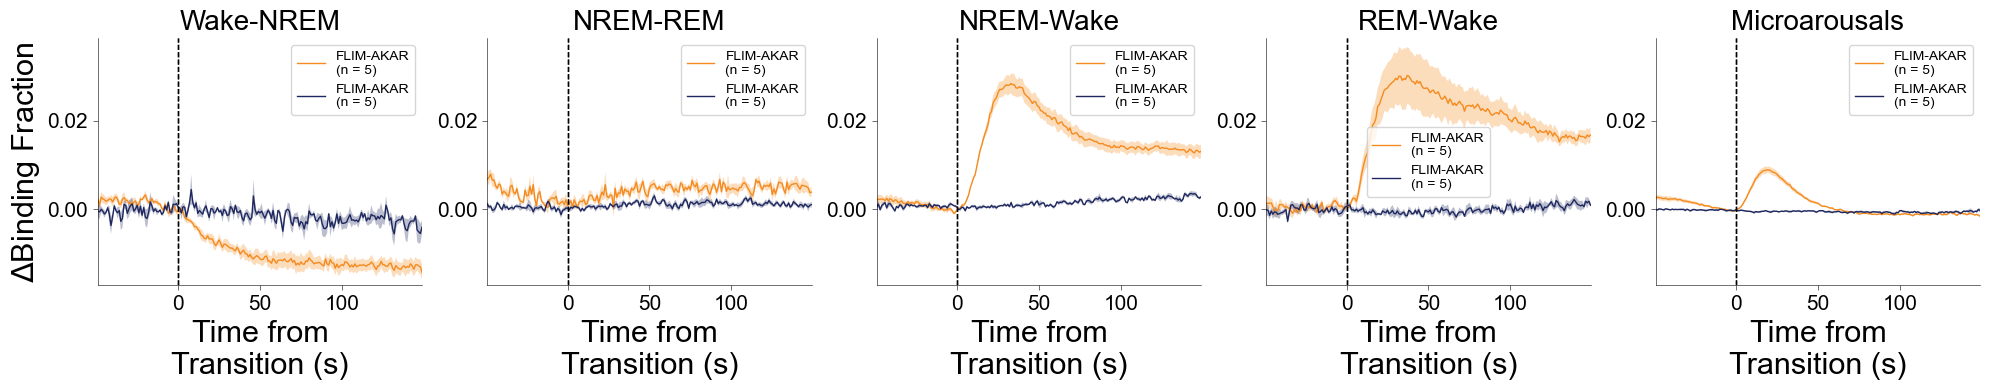

In [9]:
these_transitions = ['Wake-NREM','NREM-REM','NREM-Wake','REM-Wake','Microarousals']
window = [50,150] #plotting window [seconds before, seconds after]
intensity = False #True/False include intensity plots also
diff_wake = False 
shuffled = False # True/False include shuffled data in plot
fig_dict = False # False unless you have a fig dictionary already
long_short_wake = True
long_short_NREM = True
NREM_cutoff = 100
wake_cutoff = 100
just_dictionary = False #No plots, just data
axes_width = 0.4
color_list = ['#F58B1F','#1F285E']
just_dictionary = False

lifetime_dicts = []
for i,f in enumerate(FLP_classes_dicts):
    color_dict = {k: color_list[i] for k in these_transitions}
    fig_dict, lifetime_dict = PKA.transition_triggered_lifetime(f['Experiment Classes'], f['Experiment Names'], f['Animal Names'],
                                                        window = window, savedir = savedir, these_transitions = these_transitions,
                                                        intensity = intensity, diff_wake = diff_wake, shuffled = shuffled, 
                                                        fig_dict = fig_dict, color_dict = color_dict, long_short_wake = long_short_wake, 
                                                        long_short_NREM = long_short_NREM, NREM_cutoff = NREM_cutoff, 
                                                        wake_cutoff = wake_cutoff, raw_lifetime = raw_lifetime, 
                                                        just_dictionary = just_dictionary, axes_width = axes_width, zscore = zscore)
    lifetime_dicts.append(lifetime_dict)
for a in fig_dict['Lifetime']['Axes']:
    a.legend()
if savedir:
    fig_dict['Lifetime']['Figure'].savefig(savedir)

In [16]:
#Run the stats
all_pvals = {'Reference': 'A_T391A'}
these_outcomes = ['NREM-Wake', 'REM-Wake', 'Microarousals', 'Wake-NREM', 'NREM-REM']
amp_windows = {'NREM-Wake': [30, 40],
               'REM-Wake': [30, 40],
               'Microarousals': [10,30], 
               'Wake-NREM':[40, 65], 
               'NREM-REM':[40, 65]}
slope = False
sleep_slope_win = [30,100]
wake_slope_win = [0,20]
quant_dicts = {experimental_sensor:PKA.transition_triggered_quant(lifetime_dicts[0], amp_windows, slope = slope),
              'T391A':PKA.transition_triggered_quant(lifetime_dicts[1], amp_windows, slope = slope)}

grouped_expnames = [quant_dicts[experimental_sensor]['Experiment Name'],quant_dicts['T391A']['Experiment Name']]
grouped_mouseIDs = [quant_dicts[experimental_sensor]['Mouse ID'],quant_dicts['T391A']['Mouse ID']]
group_labels = ['A_T391A',experimental_sensor]

data_categories = quant_dicts[experimental_sensor]['LFT Quant'][experimental_sensor].keys()
all_results = {}
for c in data_categories:
    grouped_data = [
        quant_dicts[experimental_sensor]['LFT Quant'][experimental_sensor][c],
        quant_dicts['T391A']['LFT Quant'][experimental_sensor][c]
    ]
    stage1_df, perm_result, welch_result = PKA.nested_analysis_stats_v2(
        grouped_data, grouped_expnames, grouped_mouseIDs, group_labels
    )
    all_results[c] = {
        'stage1': stage1_df,
        'perm': perm_result,
        'welch': welch_result
    }

# for c in data_categories:
#     grouped_data = [quant_dicts[experimental_sensor]['LFT Quant'][experimental_sensor][c], quant_dicts['T391A']['LFT Quant'][experimental_sensor][c]]
#     data_df, standard_result, robust_result, pvals = PKA.nested_analysis_stats(grouped_data, grouped_expnames, 
#                                                                                grouped_mouseIDs, group_labels)
#     all_pvals[c] = pvals

Working on NREM-Wake
Working on REM-Wake
Working on Microarousals
Working on Wake-NREM
Working on NREM-REM
Working on NREM-Wake
Working on REM-Wake
Working on Microarousals
Working on Wake-NREM
Working on NREM-REM
Stage 1: Computing robust subject-level means using HuberT...
  Processed 10 subject-group combinations
  Observations with downweighted data: 0

=== Stage 1: per-animal robust means ===
Mouse_ID     Group  robust_mean  robust_se  n_obs
 2647-10   A_T391A     0.024211   0.003346     33
  2642-8   A_T391A     0.032793   0.004083     14
  3016-1   A_T391A     0.021466   0.002577     17
  2896-1   A_T391A     0.030610   0.006673     19
    2894   A_T391A     0.030344   0.001705     87
2987-t14 FLIM-AKAR     0.000573   0.000691     51
2986-t11 FLIM-AKAR     0.001549   0.000803     20
    4344 FLIM-AKAR     0.000761   0.000753     33
    5184 FLIM-AKAR     0.000866   0.001177     11
    5183 FLIM-AKAR     0.000627   0.001500     18

=== Stage 2 (PRIMARY): exact permutation, 252 ar

/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/genPKA_Dynamics.py:522: RuntimeWarning: Mean of empty slice
  quant.append(np.nanmean(l[averaging_window]))
/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/FLPstats.py:467: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  true_vals = vals[np.isfinite(vals)]
/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/FLPstats.py:333: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  """
/Users/lizzie/Desktop/Remote_Git/Chen_La

  Processed 10 subject-group combinations
  Observations with downweighted data: 1

=== Stage 1: per-animal robust means ===
Mouse_ID     Group  robust_mean  robust_se  n_obs
 2647-10   A_T391A     0.013451   0.008500      5
  2642-8   A_T391A     0.037035   0.002214      8
  3016-1   A_T391A     0.020349   0.003340      9
  2896-1   A_T391A     0.051157   0.008729     10
    2894   A_T391A     0.023936   0.004513     13
2987-t14 FLIM-AKAR    -0.002181   0.000514     18
2986-t11 FLIM-AKAR     0.000946   0.003114      3
    4344 FLIM-AKAR    -0.000731   0.002227      6
    5184 FLIM-AKAR    -0.001282   0.002636      7
    5183 FLIM-AKAR    -0.001303   0.001267      9

=== Stage 2 (PRIMARY): exact permutation, 252 arrangements ===
  Observed diff (A_T391A - FLIM-AKAR): 0.0301
  p (two-tailed) = 0.0079  [minimum possible = 0.0079]

=== Stage 2 (SECONDARY): Welch t-test ===
  t(4.0) = 4.479, p = 0.0107, Cohen's d = 2.83
Stage 1: Computing robust subject-level means using HuberT...
  Proces

/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/FLPstats.py:467: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  true_vals = vals[np.isfinite(vals)]
/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/FLPstats.py:333: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  """
/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/FLPstats.py:467: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will n

In [22]:
all_results['Microarousals']['welch']['p_t']

np.float64(0.0004170044728022182)